In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.calibration import CalibratedClassifierCV
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_recall_curve, auc,
    roc_auc_score, f1_score
)

%matplotlib inline
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")

In [34]:
X_train = pd.read_csv('../data/X_train.csv')
X_test  = pd.read_csv('../data/X_test.csv')
y_train = pd.read_csv('../data/y_train.csv').squeeze()   
y_test  = pd.read_csv('../data/y_test.csv').squeeze()

print("Train:", X_train.shape, "| Test:", X_test.shape)
print("Train frauds:", y_train.sum(), "| Test frauds:", y_test.sum())

Train: (227845, 30) | Test: (56962, 30)
Train frauds: 394 | Test frauds: 98


In [35]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.linear_model import SGDClassifier


base_model = SGDClassifier(
    loss='log_loss',
    alpha=1e-4,
    class_weight='balanced',
    max_iter=1000,
    random_state=42,
    n_jobs=-1
)


calibrated_model = CalibratedClassifierCV(
    base_model,
    method='sigmoid',   
    cv=3
)

calibrated_model.fit(X_train, y_train)


y_scores = calibrated_model.predict_proba(X_test)[:, 1]

print("Probability range:", y_scores.min(), "to", y_scores.max())
print("Sample:", y_scores[:10])

Probability range: 1.5379066578499653e-08 to 0.9999997989875719
Sample: [0.00036043 0.00052969 0.00021007 0.00044295 0.00275912 0.00044114
 0.00011874 0.0004415  0.00070397 0.00019106]


In [36]:
y_pred_default = (y_scores >= 0.5).astype(int)

print("=== Default Threshold (0.5) ===")
print(confusion_matrix(y_test, y_pred_default))
print()
print(classification_report(y_test, y_pred_default, digits=4))

=== Default Threshold (0.5) ===
[[56850    14]
 [   40    58]]

              precision    recall  f1-score   support

           0     0.9993    0.9998    0.9995     56864
           1     0.8056    0.5918    0.6824        98

    accuracy                         0.9991     56962
   macro avg     0.9024    0.7958    0.8409     56962
weighted avg     0.9990    0.9991    0.9990     56962



In [37]:
precision, recall, thresholds = precision_recall_curve(y_test, y_scores)

auprc = auc(recall, precision)
roc   = roc_auc_score(y_test, y_scores)

print(f"AUPRC (Area Under PR Curve): {auprc:.4f}")
print(f"ROC-AUC:                      {roc:.4f}")
print(f"Baseline AUPRC (random):      {y_test.mean():.4f}")

AUPRC (Area Under PR Curve): 0.7196
ROC-AUC:                      0.9639
Baseline AUPRC (random):      0.0017


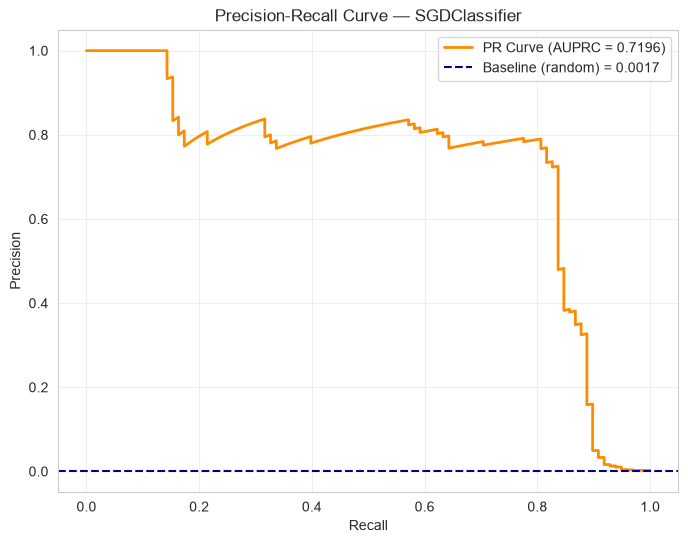

In [38]:
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='darkorange', lw=2,
         label=f'PR Curve (AUPRC = {auprc:.4f})')
plt.axhline(y=y_test.mean(), color='navy', linestyle='--',
            label=f'Baseline (random) = {y_test.mean():.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve — SGDClassifier')
plt.legend(loc='best')
plt.grid(alpha=0.3)
plt.show()

In [44]:


precision, recall, thresholds = precision_recall_curve(y_test, y_scores)

f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
best_idx = np.argmax(f1_scores[:-1])
best_threshold = thresholds[best_idx]

print(f"Best threshold (max F1): {best_threshold:.4f}")
print(f"  Precision: {precision[best_idx]:.4f}")
print(f"  Recall:    {recall[best_idx]:.4f}")
print(f"  F1:        {f1_scores[best_idx]:.4f}")

Best threshold (max F1): 208.6009
  Precision: 0.8316
  Recall:    0.8061
  F1:        0.8187


In [40]:
y_pred_best = (y_scores >= best_threshold).astype(int)

print(f"=== Threshold = {best_threshold:.4f} ===")
print(confusion_matrix(y_test, y_pred_best))
print()
print(classification_report(y_test, y_pred_best, digits=4))

=== Threshold = 208.6009 ===
[[56848    16]
 [   19    79]]

              precision    recall  f1-score   support

           0     0.9997    0.9997    0.9997     56864
           1     0.8316    0.8061    0.8187        98

    accuracy                         0.9994     56962
   macro avg     0.9156    0.9029    0.9092     56962
weighted avg     0.9994    0.9994    0.9994     56962



In [41]:
def summarize(y_true, y_pred, label):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        'Threshold': label,
        'Precision': tp / (tp + fp) if (tp + fp) else 0,
        'Recall':    tp / (tp + fn) if (tp + fn) else 0,
        'F1':        f1_score(y_true, y_pred),
        'False Alarms (FP)': fp,
        'Missed Frauds (FN)': fn
    }

summary = pd.DataFrame([
    summarize(y_test, y_pred_default, '0.50'),
    summarize(y_test, y_pred_best,    f'{best_threshold:.4f}')
])
summary

,Threshold,Precision,Recall,F1,False Alarms (FP),Missed Frauds (FN)
0,0.50,0.805556,0.591837,0.682353,14,40
1,208.6009,0.831579,0.806122,0.818653,16,19


In [45]:
joblib.dump(calibrated_model, '../models/sgd_fraud_model.pkl')
joblib.dump(best_threshold,   '../models/best_threshold.pkl')
print("Calibrated model and probability threshold saved.")

Calibrated model and probability threshold saved.


In [48]:
y_proba = calibrated_model.predict_proba(X_test)[:, 1]


precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
best_idx = np.argmax(f1_scores[:-1])
best_threshold = thresholds[best_idx]
auprc = auc(recall, precision)


y_pred = (y_proba >= best_threshold).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()


bundle = {
    'model': calibrated_model,
    'threshold': float(best_threshold),
    'auprc': float(auprc),
    'precision': float(tp / (tp + fp)),
    'recall': float(tp / (tp + fn)),
    'f1': float(f1_score(y_test, y_pred)),
    'metrics': {
        'AUPRC': round(auprc, 4),
        'Precision': round(tp / (tp + fp), 4),
        'Recall': round(tp / (tp + fn), 4),
        'F1': round(f1_score(y_test, y_pred), 4),
        'True Positives': int(tp),
        'False Positives': int(fp),
        'False Negatives': int(fn),
        'True Negatives': int(tn)
    }
}

joblib.dump(bundle, '../models/fraud_model_bundle.pkl')
print("Bundle saved ")
print("Threshold:", round(best_threshold, 4))
print("Metrics:", bundle['metrics'])

Bundle saved 
Threshold: 0.1334
Metrics: {'AUPRC': 0.7196, 'Precision': np.float64(0.79), 'Recall': np.float64(0.8061), 'F1': 0.798, 'True Positives': 79, 'False Positives': 21, 'False Negatives': 19, 'True Negatives': 56843}


In [49]:
import joblib

# Load the existing bundle
bundle = joblib.load('../models/fraud_model_bundle.pkl')

# Re-save with compression (reduces size ~5-10x)
joblib.dump(bundle, '../models/fraud_model_bundle.pkl', compress=3)

import os
print("New size (MB):", round(os.path.getsize('../models/fraud_model_bundle.pkl') / 1e6, 2))

New size (MB): 0.0
